# Data processing 

In [1]:
!pip install split_folders

In [18]:
import matplotlib.pyplot as plt
import matplotlib.image as mping
import random
import splitfolders
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os
import tensorflow as tf
from tensorflow.keras import layers

In [3]:
os.makedirs('output')
os.makedirs('output/train')
os.makedirs('output/val')
os.makedirs('output/test')

loc = "/kaggle/input/skin-diseases-image-dataset/IMG_CLASSES"

splitfolders.ratio(loc,output ="output",ratio = (0.80,.1,.1))

Copying files: 27153 files [05:22, 84.13 files/s] 


In [4]:
def random_image(val_dir,val_class):
    folder = val_dir +val_class
    random_image = random.sample(os.listdir(folder),1)
    img = mping.imread(folder + "/" + random_image[0])
    plt.imshow(img)
    plt.title(val_class)
    return img

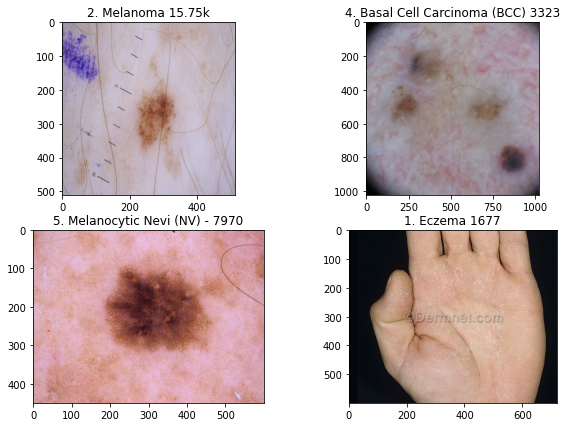

In [5]:
fig = plt.figure(figsize=(10, 7))
#Add an Axes to the figure as part of a subplot arrangement(Three integers (nrows, ncols, index).)
fig.add_subplot(2,2,1)
img_1 = random_image(val_dir = "./output/val/",val_class = "2. Melanoma 15.75k")
fig.add_subplot(2,2,2)
img_2 = random_image(val_dir = "./output/val/",val_class = "4. Basal Cell Carcinoma (BCC) 3323")
fig.add_subplot(2,2,3)
img_3 = random_image(val_dir = "./output/val/",val_class = "5. Melanocytic Nevi (NV) - 7970")
fig.add_subplot(2,2,4)
img4 = random_image(val_dir = "./output/val/",val_class = "1. Eczema 1677")


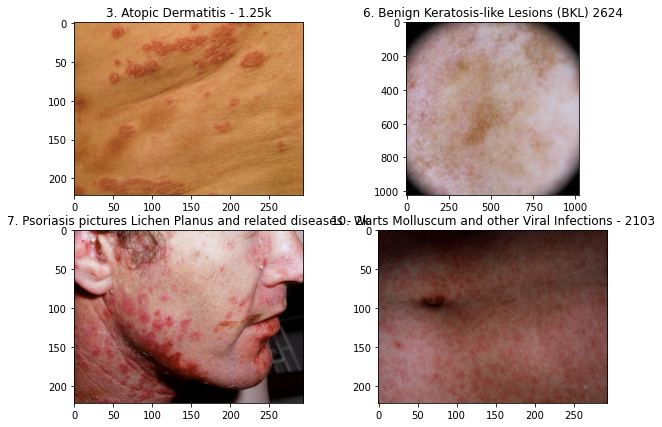

In [6]:
fig = plt.figure(figsize=(10, 7))
#Add an Axes to the figure as part of a subplot arrangement(Three integers (nrows, ncols, index).)
fig.add_subplot(2,2,1)
img_1 = random_image(val_dir = "./output/val/",val_class = "3. Atopic Dermatitis - 1.25k")
fig.add_subplot(2,2,2)
img_2 = random_image(val_dir = "./output/val/",val_class = "6. Benign Keratosis-like Lesions (BKL) 2624")
fig.add_subplot(2,2,3)
img_3 = random_image(val_dir = "./output/val/",val_class = "7. Psoriasis pictures Lichen Planus and related diseases - 2k")
fig.add_subplot(2,2,4)
img4 = random_image(val_dir = "./output/val/",val_class = "10. Warts Molluscum and other Viral Infections - 2103")

# Loading and Preparing Data 

In [8]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

train_dir = "./output/train"
test_dir =  "./output/test"
val_dir = "./output/val"

train_data = image_dataset_from_directory(train_dir,label_mode = "categorical",
                                          image_size = (224,224),batch_size = 32,
                                         shuffle = True,seed = 42)
test_data = image_dataset_from_directory(test_dir,label_mode = "categorical",
                                          image_size = (224,224),batch_size = 32,
                                         shuffle = False,seed = 42)
val_data = image_dataset_from_directory(val_dir,label_mode = "categorical",
                                          image_size = (224,224),batch_size = 32,
                                         shuffle = False,seed = 42)

Found 21719 files belonging to 10 classes.
Found 2723 files belonging to 10 classes.
Found 2711 files belonging to 10 classes.


# EarlyStopping
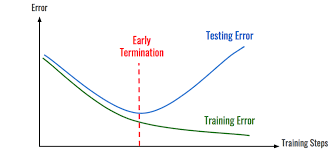

# ReduceLROnPlateau
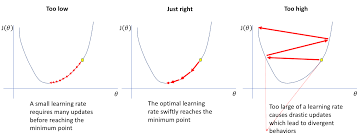

In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor = "val_loss",patience = 6,
                                             min_delta = 0.0001)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor = "val_loss",factor = 0.2,
                                                patience = 4,min_lr = 1e-7)


# Model Setup

### EfficientNetB7

> EfficientNet is a convolutional neural network architecture and scaling method that uniformly scales all dimensions of depth/width/resolution using a compound coefficient. Unlike conventional practice that arbitrary scales these factors, the EfficientNet scaling method uniformly scales network width, depth, and resolution with a set of fixed scaling coefficients

![](https://www.researchgate.net/publication/358902226/figure/fig6/AS:1132398989328389@1646996366464/EfficientNetB7-architecture.ppm)



In [10]:
model = tf.keras.applications.EfficientNetB7(include_top = False)
model.trainable = False
#To "freeze" a layer means to exclude it from training, i.e. its weights will never be updated.

258088960/258076736 [==============================] - 1s 0us/step


In [11]:
from tensorflow.keras.layers.experimental import preprocessing

data_aug = tf.keras.Sequential([
    preprocessing.RandomWidth(0.2),
    preprocessing.RandomHeight(0.2),
    preprocessing.RandomRotation(0.2),
    preprocessing.RandomFlip("horizontal")
],name = "data_augmentation_layer")

In [12]:
inputs = layers.Input(shape = (224,224,3),name = "input_layer")
x = data_aug(inputs)
x = model(x)
x = layers.GlobalAvgPool2D(name = "pooling_layer")(x)
# parameter used to specify the size of the output generated from the layer.
x = layers.Dense(32,activation = "relu",kernel_initializer = tf.keras.initializers.he_normal())(x)
x = layers.Dense(10)(x)
outputs = layers.Activation("softmax",dtype = tf.float32)(x)
model = tf.keras.Model(inputs,outputs)
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_layer (InputLayer)     [(None, 224, 224, 3)]     0         
_________________________________________________________________
data_augmentation_layer (Seq (None, None, None, 3)     0         
_________________________________________________________________
efficientnetb7 (Functional)  (None, None, None, 2560)  64097687  
_________________________________________________________________
pooling_layer (GlobalAverage (None, 2560)              0         
_________________________________________________________________
dense (Dense)                (None, 32)                81952     
_________________________________________________________________
dense_1 (Dense)              (None, 10)                330       
_________________________________________________________________
activation (Activation)      (None, 10)                0     

Once the model is created, you can config the model with 
* losses and metrics with model.compile(), 
* train the model with model.fit(),
* or use the model to do prediction with model.predict().

In [13]:
model.compile(loss = tf.keras.losses.CategoricalCrossentropy(),optimizer = tf.keras.optimizers.Adam(),metrics = ["accuracy"])

In [14]:
history_1 = model.fit(train_data,epochs =20 , validation_data = val_data, 
                      callbacks = [early_stop,reduce_lr])

Epoch 1/20
679/679 [==============================] - 564s 795ms/step - loss: 1.1114 - accuracy: 0.5801 - val_loss: 0.9488 - val_accuracy: 0.6363
Epoch 2/20
679/679 [==============================] - 439s 645ms/step - loss: 0.9530 - accuracy: 0.6380 - val_loss: 0.8949 - val_accuracy: 0.6669
Epoch 3/20
679/679 [==============================] - 388s 571ms/step - loss: 0.8970 - accuracy: 0.6591 - val_loss: 0.8563 - val_accuracy: 0.6758
Epoch 4/20
679/679 [==============================] - 365s 536ms/step - loss: 0.8651 - accuracy: 0.6727 - val_loss: 0.8426 - val_accuracy: 0.6854
Epoch 5/20
679/679 [==============================] - 348s 511ms/step - loss: 0.8428 - accuracy: 0.6803 - val_loss: 0.8301 - val_accuracy: 0.6868
Epoch 6/20
679/679 [==============================] - 330s 485ms/step - loss: 0.8287 - accuracy: 0.6840 - val_loss: 0.8232 - val_accuracy: 0.6913
Epoch 7/20
679/679 [==============================] - 334s 491ms/step - loss: 0.7977 - accuracy: 0.6998 - val_loss: 0.8247 -

In [15]:
print("Testing Accuracy",model.evaluate(test_data)) 

86/86 [==============================] - 33s 380ms/step - loss: 0.7664 - accuracy: 0.7242
Testing Accuracy [0.7663764953613281, 0.7242012619972229]


## Evaluation 

Extracting true labels and generating predictions...

CLASSIFICATION REPORT (Precision, Recall, F1-Score)
                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677       0.44      0.59      0.50       169
           10. Warts Molluscum and other Viral Infections - 2103       0.57      0.61      0.59       211
                                              2. Melanoma 15.75k       0.88      0.81      0.84       314
                                    3. Atopic Dermatitis - 1.25k       0.47      0.50      0.48       127
                              4. Basal Cell Carcinoma (BCC) 3323       0.77      0.90      0.83       333
                                 5. Melanocytic Nevi (NV) - 7970       0.90      0.90      0.90       797
                     6. Benign Keratosis-like Lesions (BKL) 2624       0.71      0.59      0.65       209
   7. Psoriasis pictures Lichen Planus and re

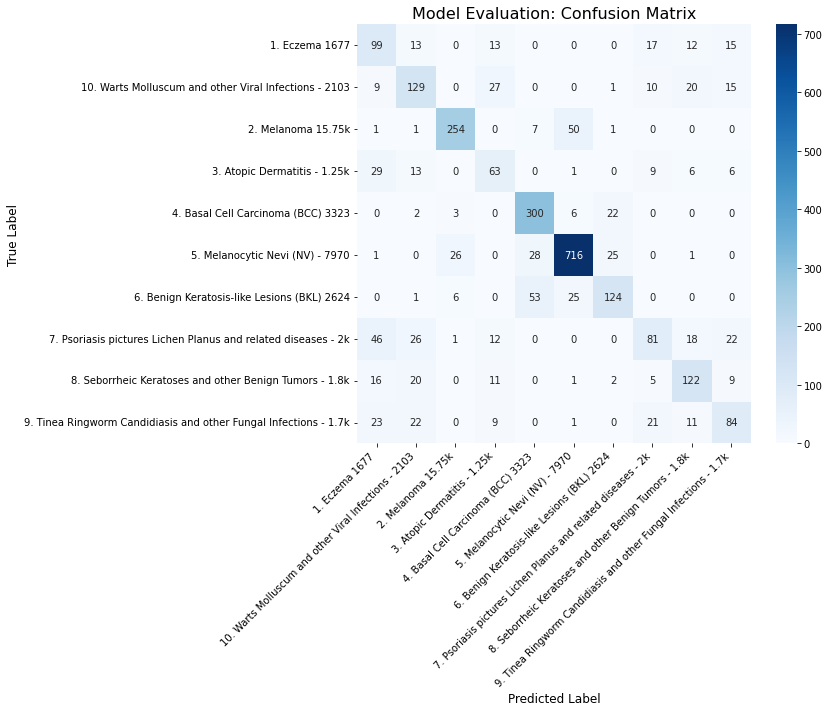

In [19]:


# 1. Choose which dataset to evaluate (usually test_data or val_data)
# Good job setting shuffle=False on these! That is required for accurate evaluation.
evaluation_data = test_data 
class_names = evaluation_data.class_names

print("Extracting true labels and generating predictions...")

# 2. Extract true labels from the dataset
y_true = []
for images, labels in evaluation_data:
    # Because of label_mode="categorical", we use argmax to convert one-hot arrays back to integer labels
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    
y_true = np.array(y_true)

# 3. Get the model's predictions
# The model outputs probabilities (softmax), so we use argmax to find the predicted class index
predictions = model.predict(evaluation_data)
y_pred = np.argmax(predictions, axis=1)

# 4. Print Precision, Recall, and F1-Score
print("\n" + "="*50)
print("CLASSIFICATION REPORT (Precision, Recall, F1-Score)")
print("="*50)
# classification_report handles all the heavy lifting for these metrics
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# 5. Generate and Plot the Confusion Matrix
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Model Evaluation: Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotates the x labels so they don't overlap
plt.tight_layout()
plt.show()

# Save Model

In [16]:
model.save('my_model.h5')

/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)
